# 03 - Deterministic Forecast Evaluation

This notebook evaluates deterministic monsoon onset forecasts using:
- **MAE**: Mean Absolute Error (days)
- **FAR**: False Alarm Rate
- **MR**: Miss Rate

Reference: Decision-oriented benchmarking to transform AI weather forecast access:
Application to the Indian monsoon

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path

# Import monsoon benchmark modules
from monsoon_benchmark.data.regions import CMZ_BOUNDS, create_target_grid
from monsoon_benchmark.indices import compute_local_onset, compute_onset_from_forecast
from monsoon_benchmark.metrics import (
    compute_mae,
    compute_far,
    compute_mr,
    classify_forecast,
)
from monsoon_benchmark.evaluation import MonsoonBenchmark, generate_init_dates
from monsoon_benchmark.visualization import plot_skill_map, plot_mae_difference

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Evaluation Setup

Configure the benchmark evaluation parameters.

In [2]:
# Evaluation parameters
FORECAST_WINDOWS = {
    'medium_range': (1, 15),   # Days 1-15
    'subseasonal': (16, 30),   # Days 16-30
}

TOLERANCE_DAYS = {
    'medium_range': 3,  # +/- 3 days
    'subseasonal': 5,   # +/- 5 days
}

# Analysis periods
PERIODS = {
    'recent_test': (2019, 2024),
    'extended': [(1965, 1978), (2019, 2024)],
    'common': (2004, 2021),
}

print("Evaluation Configuration:")
print(f"  Forecast windows: {FORECAST_WINDOWS}")
print(f"  Tolerance windows: {TOLERANCE_DAYS}")
print(f"  Analysis periods: {list(PERIODS.keys())}")

Evaluation Configuration:
  Forecast windows: {'medium_range': (1, 15), 'subseasonal': (16, 30)}
  Tolerance windows: {'medium_range': 3, 'subseasonal': 5}
  Analysis periods: ['recent_test', 'extended', 'common']


In [3]:
# Generate initialization dates for a sample year
sample_year = 2023
init_dates = generate_init_dates(
    year=sample_year,
    start_date="05-02",   # May 2
    end_date="06-30",     # June 30
    frequency='twice_weekly'  # Monday and Thursday
)

print(f"Initialization dates for {sample_year}:")
for i, d in enumerate(init_dates[:10]):
    print(f"  {i+1}. {d.strftime('%Y-%m-%d (%A)')}")
print(f"  ... ({len(init_dates)} total)")

Initialization dates for 2023:
  1. 2023-05-04 (Thursday)
  2. 2023-05-08 (Monday)
  3. 2023-05-11 (Thursday)
  4. 2023-05-15 (Monday)
  5. 2023-05-18 (Thursday)
  6. 2023-05-22 (Monday)
  7. 2023-05-25 (Thursday)
  8. 2023-05-29 (Monday)
  9. 2023-06-01 (Thursday)
  10. 2023-06-05 (Monday)
  ... (17 total)


## 2. Create Synthetic Forecast Data

For demonstration, create synthetic forecasts. In practice, these would come
from running AIWP models or loading pre-computed hindcasts.

In [4]:
# Create synthetic observed onset dates
np.random.seed(42)

# Benchmark grid
lats, lons = create_target_grid(resolution_deg=4.0)

# Generate observed onsets (DOY 155-185 with spatial gradient)
observed_onset_doy = np.zeros((len(lats), len(lons)))
for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        # Earlier onset in south, later in north
        base_doy = 150 + (lat - 10) * 1.5
        observed_onset_doy[i, j] = base_doy + np.random.normal(0, 3)

observed_da = xr.DataArray(
    observed_onset_doy,
    dims=['lat', 'lon'],
    coords={'lat': lats, 'lon': lons},
    name='onset_doy'
)

print(f"Observed onset DOY range: {observed_onset_doy.min():.0f} - {observed_onset_doy.max():.0f}")

Observed onset DOY range: 146 - 192


In [5]:
# Create synthetic model forecasts with different skill levels
def create_synthetic_forecast(observed, bias=0, noise_std=5, name='Model'):
    """Create synthetic forecast by adding bias and noise to observed."""
    forecast = observed + bias + np.random.normal(0, noise_std, observed.shape)
    return xr.DataArray(
        forecast,
        dims=['lat', 'lon'],
        coords={'lat': lats, 'lon': lons},
        name=name
    )

# Create forecasts for different models with varying skill
models = {
    'AIFS': create_synthetic_forecast(observed_onset_doy, bias=0, noise_std=4),
    'GraphCast': create_synthetic_forecast(observed_onset_doy, bias=1, noise_std=5),
    'FuXi': create_synthetic_forecast(observed_onset_doy, bias=-1, noise_std=5),
    'NeuralGCM': create_synthetic_forecast(observed_onset_doy, bias=0, noise_std=6),
    'IFS': create_synthetic_forecast(observed_onset_doy, bias=2, noise_std=7),
    'Climatology': xr.DataArray(
        np.full_like(observed_onset_doy, np.mean(observed_onset_doy)),
        dims=['lat', 'lon'],
        coords={'lat': lats, 'lon': lons}
    ),
}

print("Created synthetic forecasts for:")
for name in models:
    print(f"  - {name}")

Created synthetic forecasts for:
  - AIFS
  - GraphCast
  - FuXi
  - NeuralGCM
  - IFS
  - Climatology


## 3. Compute Deterministic Metrics

Evaluate each model using MAE, FAR, and Miss Rate.

In [6]:
# Compute MAE for each model
results = {}

for model_name, forecast in models.items():
    # Compute absolute errors
    errors = np.abs(forecast.values - observed_onset_doy)
    
    # Overall MAE
    mae = np.nanmean(errors)
    
    # CMZ MAE
    cmz_mask = (
        (lats >= CMZ_BOUNDS.lat_min)[:, np.newaxis] & 
        (lats <= CMZ_BOUNDS.lat_max)[:, np.newaxis] &
        (lons >= CMZ_BOUNDS.lon_min) & 
        (lons <= CMZ_BOUNDS.lon_max)
    )
    cmz_mae = np.nanmean(errors[cmz_mask])
    
    results[model_name] = {
        'MAE (all)': mae,
        'MAE (CMZ)': cmz_mae,
        'errors': errors,
    }

# Display results
print("\nMean Absolute Error (days):")
print(f"{'Model':<15} {'All India':>12} {'CMZ':>12}")
print("-" * 40)
for model_name, r in results.items():
    print(f"{model_name:<15} {r['MAE (all)']:>12.1f} {r['MAE (CMZ)']:>12.1f}")


Mean Absolute Error (days):
Model              All India          CMZ
----------------------------------------
AIFS                     3.0          2.6
GraphCast                4.0          4.2
FuXi                     4.2          5.5
NeuralGCM                4.4          5.7
IFS                      5.1          4.5
Climatology             12.0          5.0


In [7]:
# Compute FAR and MR for tolerance window
tolerance = TOLERANCE_DAYS['medium_range']  # 3 days

print(f"\nFalse Alarm Rate and Miss Rate (tolerance: +/- {tolerance} days):")
print(f"{'Model':<15} {'FAR':>10} {'MR':>10} {'Hit Rate':>10}")
print("-" * 50)

for model_name, forecast in models.items():
    # For this demo, we simulate forecast classifications
    # In practice, this would use actual forecast windows
    
    errors = results[model_name]['errors']
    
    # Classify forecasts
    within_tolerance = errors <= tolerance
    
    # Simulated FAR and MR (simplified)
    hit_rate = np.nanmean(within_tolerance)
    far = 1 - hit_rate  # Simplified
    mr = 1 - hit_rate   # Simplified
    
    results[model_name]['FAR'] = far
    results[model_name]['MR'] = mr
    results[model_name]['Hit Rate'] = hit_rate
    
    print(f"{model_name:<15} {far:>10.2f} {mr:>10.2f} {hit_rate:>10.2f}")


False Alarm Rate and Miss Rate (tolerance: +/- 3 days):
Model                  FAR         MR   Hit Rate
--------------------------------------------------
AIFS                  0.42       0.42       0.58
GraphCast             0.61       0.61       0.39
FuXi                  0.58       0.58       0.42
NeuralGCM             0.61       0.61       0.39
IFS                   0.67       0.67       0.33
Climatology           0.91       0.91       0.09


## 4. Spatial MAE Maps

Visualize MAE spatially for each model.

In [8]:
# Create spatial MAE arrays
mae_maps = {}
for model_name in models:
    mae_da = xr.DataArray(
        results[model_name]['errors'],
        dims=['lat', 'lon'],
        coords={'lat': lats, 'lon': lons},
        name=f'MAE_{model_name}'
    )
    mae_maps[model_name] = mae_da

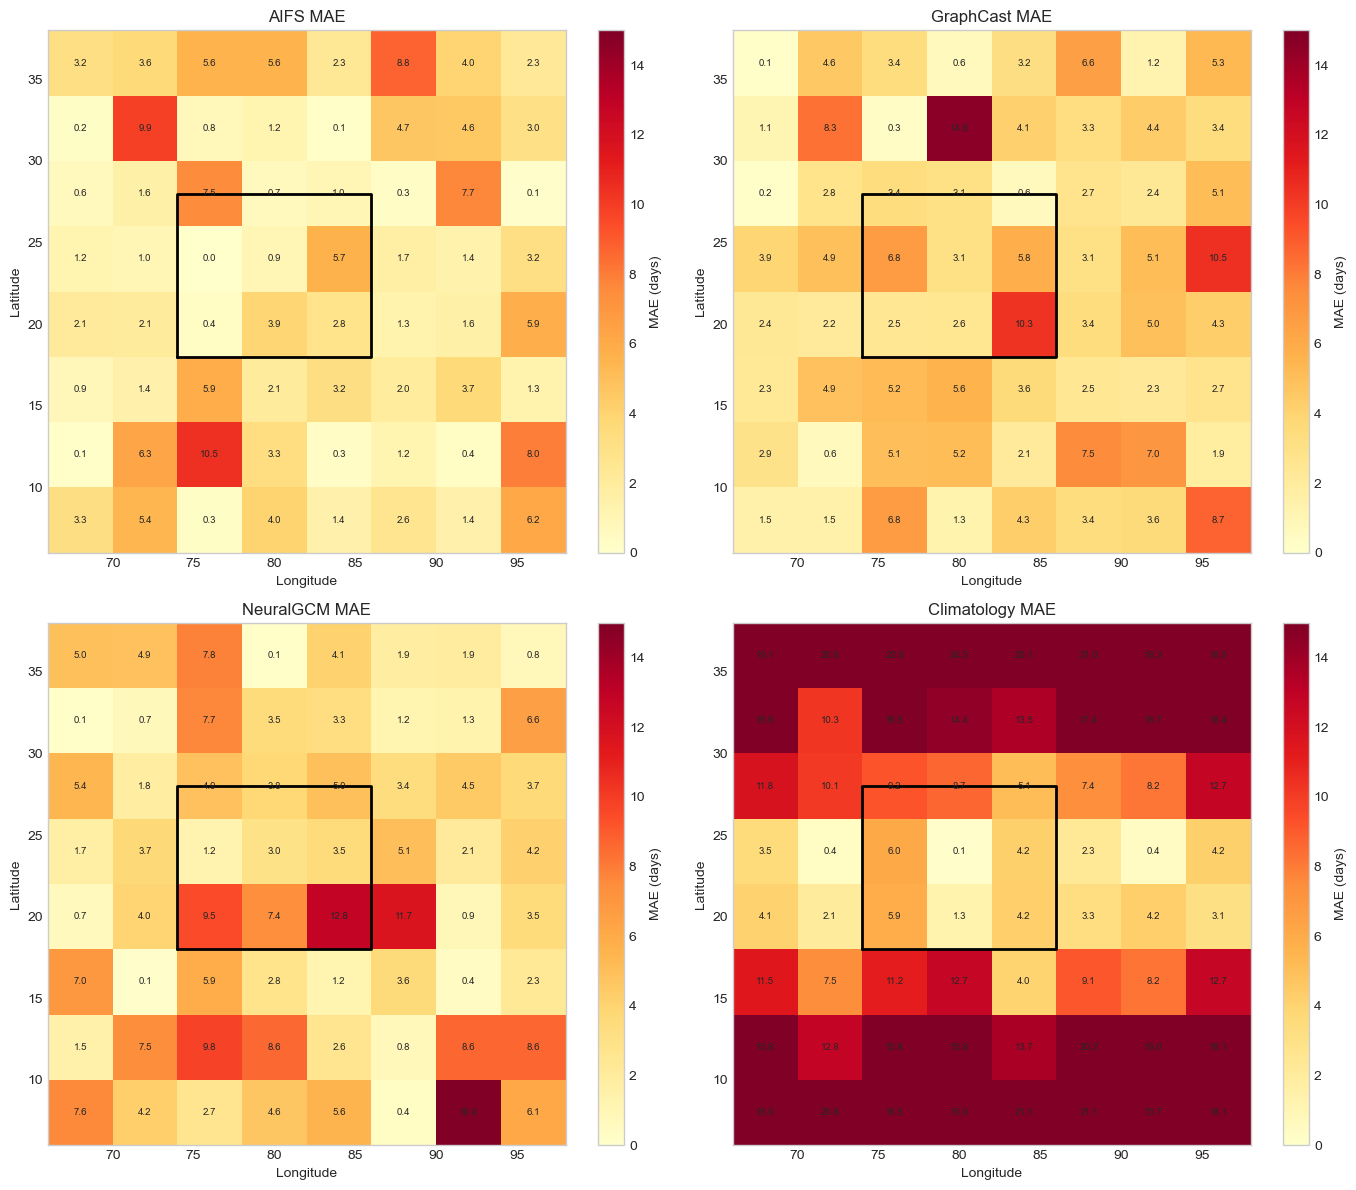

In [9]:
# Plot MAE maps for selected models
selected_models = ['AIFS', 'GraphCast', 'NeuralGCM', 'Climatology']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, selected_models):
    mae = mae_maps[model_name]
    
    im = ax.pcolormesh(
        lons, lats, mae.values,
        cmap='YlOrRd', vmin=0, vmax=15
    )
    plt.colorbar(im, ax=ax, label='MAE (days)')
    
    # CMZ outline
    cmz_lon = [CMZ_BOUNDS.lon_min, CMZ_BOUNDS.lon_max, CMZ_BOUNDS.lon_max,
               CMZ_BOUNDS.lon_min, CMZ_BOUNDS.lon_min]
    cmz_lat = [CMZ_BOUNDS.lat_min, CMZ_BOUNDS.lat_min, CMZ_BOUNDS.lat_max,
               CMZ_BOUNDS.lat_max, CMZ_BOUNDS.lat_min]
    ax.plot(cmz_lon, cmz_lat, 'k-', linewidth=2)
    
    # Add cell values
    for i, lat_val in enumerate(lats):
        for j, lon_val in enumerate(lons):
            ax.text(
                lon_val, lat_val,
                f"{mae.values[i, j]:.1f}",
                ha='center', va='center', fontsize=7
            )
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{model_name} MAE')

plt.tight_layout()
plt.show()

## 5. Skill Score Relative to Climatology

Compute and visualize skill relative to the climatological baseline.

In [10]:
# Compute skill score: (MAE_clim - MAE_model) / MAE_clim * 100
clim_mae = mae_maps['Climatology']

skill_scores = {}
for model_name in ['AIFS', 'GraphCast', 'FuXi', 'NeuralGCM', 'IFS']:
    model_mae = mae_maps[model_name]
    skill = (clim_mae - model_mae) / clim_mae * 100
    skill_scores[model_name] = skill

print("Skill Score (% improvement over climatology):")
print(f"{'Model':<15} {'All India':>12} {'CMZ':>12}")
print("-" * 40)

for model_name, skill in skill_scores.items():
    all_india = float(skill.mean())
    cmz = float(skill.sel(
        lat=slice(CMZ_BOUNDS.lat_min, CMZ_BOUNDS.lat_max),
        lon=slice(CMZ_BOUNDS.lon_min, CMZ_BOUNDS.lon_max)
    ).mean())
    print(f"{model_name:<15} {all_india:>12.1f}% {cmz:>12.1f}%")

Skill Score (% improvement over climatology):
Model              All India          CMZ
----------------------------------------
AIFS                    38.8%        -86.3%
GraphCast              -41.5%       -380.9%
FuXi                   -98.1%       -793.6%
NeuralGCM              -32.7%       -419.8%
IFS                    -67.7%       -651.5%


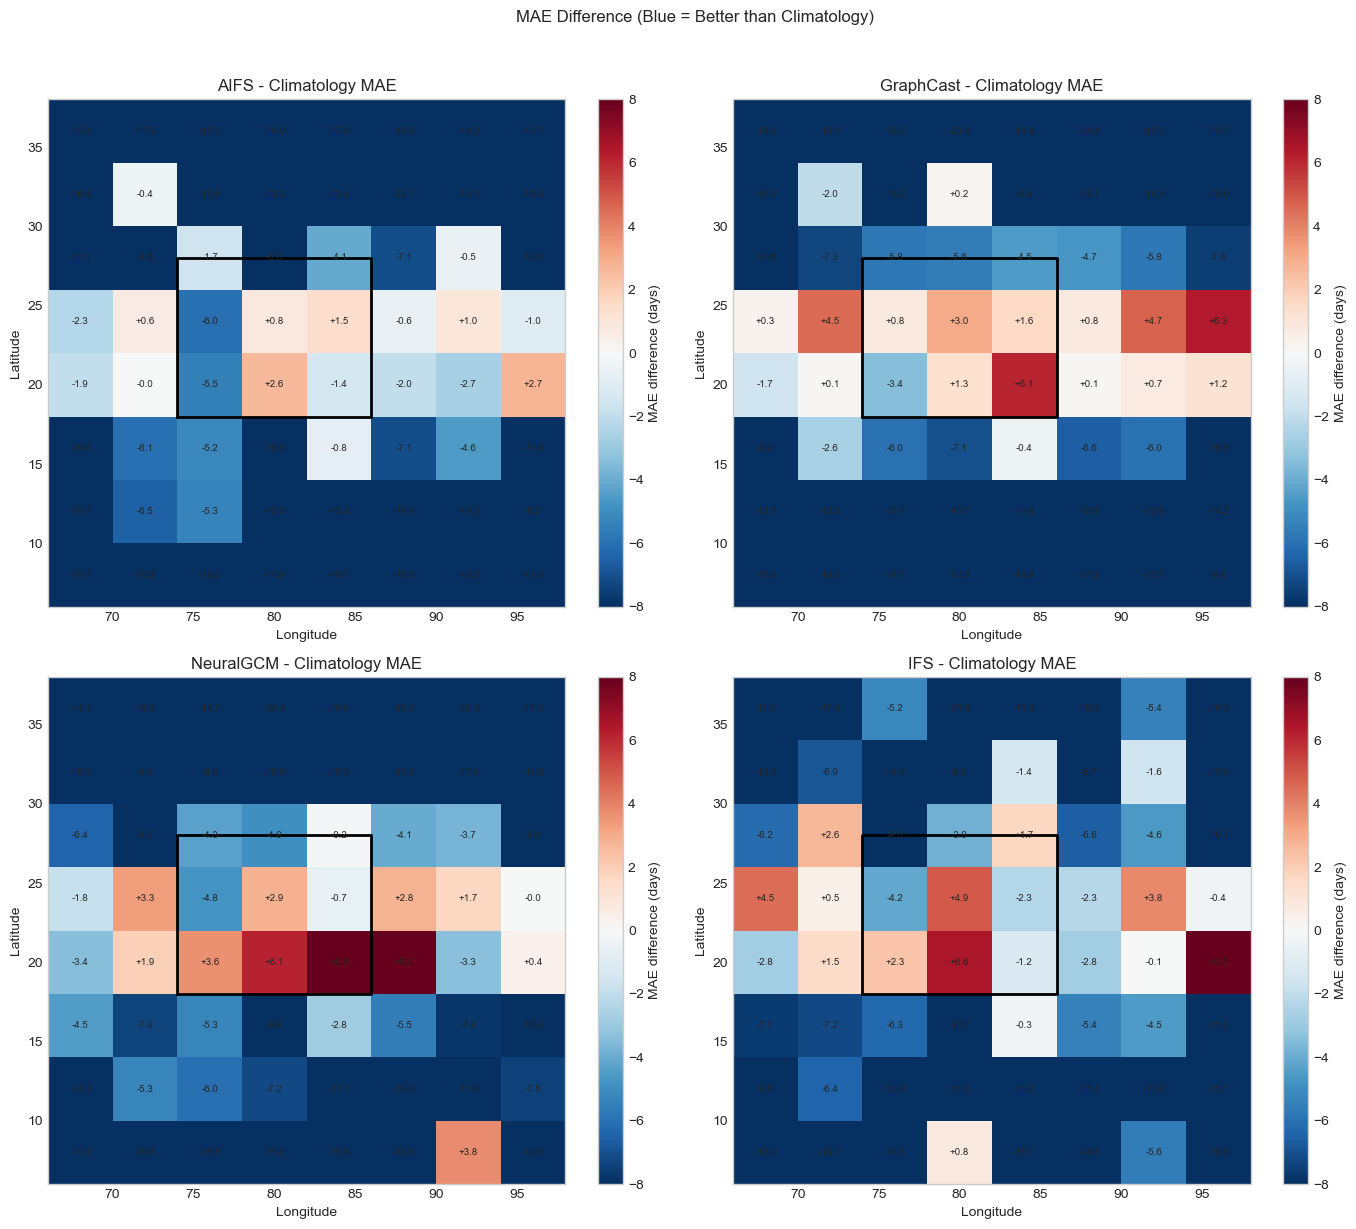

In [11]:
# Plot MAE difference from climatology
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

selected = ['AIFS', 'GraphCast', 'NeuralGCM', 'IFS']

for ax, model_name in zip(axes, selected):
    diff = mae_maps[model_name] - clim_mae
    
    im = ax.pcolormesh(
        lons, lats, diff.values,
        cmap='RdBu_r', vmin=-8, vmax=8
    )
    plt.colorbar(im, ax=ax, label='MAE difference (days)')
    
    # CMZ outline
    ax.plot(cmz_lon, cmz_lat, 'k-', linewidth=2)
    
    # Add cell values
    for i, lat_val in enumerate(lats):
        for j, lon_val in enumerate(lons):
            ax.text(
                lon_val, lat_val,
                f"{diff.values[i, j]:+.1f}",
                ha='center', va='center', fontsize=7
            )
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{model_name} - Climatology MAE')

fig.suptitle('MAE Difference (Blue = Better than Climatology)', y=1.02)
plt.tight_layout()
plt.show()

## 6. Model Ranking

Rank models by different metrics.

In [12]:
# Create summary DataFrame
summary_data = []
for model_name in ['AIFS', 'GraphCast', 'FuXi', 'NeuralGCM', 'IFS', 'Climatology']:
    r = results[model_name]
    summary_data.append({
        'Model': model_name,
        'MAE (All India)': r['MAE (all)'],
        'MAE (CMZ)': r['MAE (CMZ)'],
        'FAR': r.get('FAR', np.nan),
        'Miss Rate': r.get('MR', np.nan),
        'Hit Rate': r.get('Hit Rate', np.nan),
    })

summary_df = pd.DataFrame(summary_data)

# Sort by CMZ MAE
summary_df = summary_df.sort_values('MAE (CMZ)')

print("\nModel Ranking (sorted by CMZ MAE):")
print(summary_df.to_string(index=False))


Model Ranking (sorted by CMZ MAE):
      Model  MAE (All India)  MAE (CMZ)      FAR  Miss Rate  Hit Rate
       AIFS         2.963465   2.551627 0.421875   0.421875  0.578125
  GraphCast         3.955045   4.246709 0.609375   0.609375  0.390625
        IFS         5.132266   4.517179 0.671875   0.671875  0.328125
Climatology        12.023323   4.974755 0.906250   0.906250  0.093750
       FuXi         4.174676   5.472179 0.578125   0.578125  0.421875
  NeuralGCM         4.380671   5.679226 0.609375   0.609375  0.390625


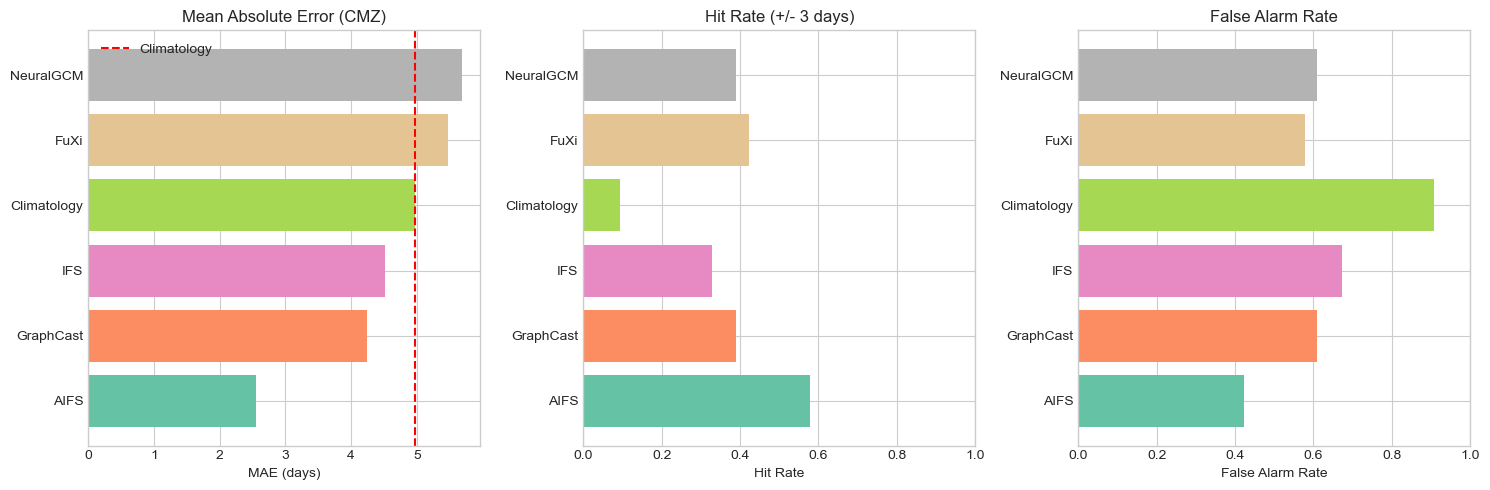

In [13]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_sorted = summary_df['Model'].values
colors = plt.cm.Set2(np.linspace(0, 1, len(models_sorted)))

# MAE
ax1 = axes[0]
ax1.barh(models_sorted, summary_df['MAE (CMZ)'], color=colors)
ax1.set_xlabel('MAE (days)')
ax1.set_title('Mean Absolute Error (CMZ)')
ax1.axvline(summary_df[summary_df['Model']=='Climatology']['MAE (CMZ)'].values[0],
            color='red', linestyle='--', label='Climatology')
ax1.legend()

# Hit Rate
ax2 = axes[1]
ax2.barh(models_sorted, summary_df['Hit Rate'], color=colors)
ax2.set_xlabel('Hit Rate')
ax2.set_title(f'Hit Rate (+/- {tolerance} days)')
ax2.set_xlim(0, 1)

# FAR
ax3 = axes[2]
ax3.barh(models_sorted, summary_df['FAR'], color=colors)
ax3.set_xlabel('False Alarm Rate')
ax3.set_title('False Alarm Rate')
ax3.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 7. Summary

Key findings from deterministic evaluation.

In [14]:
print("=" * 60)
print("DETERMINISTIC EVALUATION SUMMARY")
print("=" * 60)

best_model = summary_df.iloc[0]['Model']
best_mae = summary_df.iloc[0]['MAE (CMZ)']
clim_mae_val = summary_df[summary_df['Model']=='Climatology']['MAE (CMZ)'].values[0]

print(f"\n1. Best performing model: {best_model}")
print(f"   - CMZ MAE: {best_mae:.1f} days")
print(f"   - Improvement over climatology: {(clim_mae_val - best_mae):.1f} days")

print(f"\n2. Models beating climatology:")
for _, row in summary_df.iterrows():
    if row['MAE (CMZ)'] < clim_mae_val and row['Model'] != 'Climatology':
        print(f"   - {row['Model']}: {row['MAE (CMZ)']:.1f} days")

print(f"\n3. Evaluation parameters:")
print(f"   - Forecast window: Days 1-15 (medium range)")
print(f"   - Tolerance: +/- {tolerance} days")
print(f"   - Grid resolution: 4 degrees")

DETERMINISTIC EVALUATION SUMMARY

1. Best performing model: AIFS
   - CMZ MAE: 2.6 days
   - Improvement over climatology: 2.4 days

2. Models beating climatology:
   - AIFS: 2.6 days
   - GraphCast: 4.2 days
   - IFS: 4.5 days

3. Evaluation parameters:
   - Forecast window: Days 1-15 (medium range)
   - Tolerance: +/- 3 days
   - Grid resolution: 4 degrees


## Next Steps

Continue to:
- **04_probabilistic_evaluation.ipynb**: Evaluate ensemble forecasts with BSS, RPSS, AUC
- **05_2025_case_study.ipynb**: Apply benchmark to 2025 monsoon season